# CeliGuard Celiac Risk Training Pipeline`n

In [1]:
import os
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DEFAULT_HF_MAIN_DATASET = "ayush-yadavv/nhanes_celiac_data"
HF_MAIN_DATASET = os.getenv("HF_MAIN_DATASET_SECRET") or os.getenv("HF_MAIN_DATASET")
if not HF_MAIN_DATASET:
    try:
        from google.colab import userdata  # type: ignore
        HF_MAIN_DATASET = userdata.get("HF_MAIN_DATASET_SECRET") or DEFAULT_HF_MAIN_DATASET
    except Exception:
        HF_MAIN_DATASET = DEFAULT_HF_MAIN_DATASET
HF_TRAIN_SPLIT = "train"
HF_TEST_SPLIT = "test"
HF_MAIN_MAX_ROWS = None
# Imbalance handling strategies to compare during training.
BALANCING_STRATEGIES = [
    {"name": "none", "class_weight": False, "oversample": False},
    {"name": "class_weight_only", "class_weight": True, "oversample": False},
    {"name": "oversample_only", "class_weight": False, "oversample": True},
    {"name": "class_weight_plus_oversample", "class_weight": True, "oversample": True},
]
# Resolve paths correctly whether the notebook kernel starts in the repo root or train/.
CWD = Path.cwd().resolve()
if (CWD / "train").exists() and (CWD / "models").exists():
    PROJECT_ROOT = CWD
elif CWD.name == "train" and (CWD.parent / "models").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD
# Keep model output compatible with backend defaults.
MODEL_OUTPUT_DIR = os.getenv("MODEL_OUTPUT_DIR")
OUTPUT_DIR = Path(MODEL_OUTPUT_DIR).expanduser() if MODEL_OUTPUT_DIR else PROJECT_ROOT / "models"
OUTPUT_MODEL_PATH = OUTPUT_DIR / "celiac_risk_model.pkl"
OUTPUT_METADATA_PATH = OUTPUT_DIR / "model_metadata.pkl"
CV_FOLDS = 5
warnings.filterwarnings("ignore", message=".*IProgress not found.*")


In [2]:
NUMERIC_FEATURES = [
    "age_at_diagnosis",
    "current_age",
    "years_of_symptoms_before_diagnosis",
    "bmi",
    "followup_years",
]
CATEGORICAL_FEATURES = [
    "sex",
    "marsh_grade_at_diagnosis",
    "mucosal_healing_on_followup",
    "rcd_type",
    "smoking_status",
    "gfd_adherence",
    "family_history_of_malignancy",
    "hla_risk",
]
MISSING_INDICATOR_FEATURES = [f"{col}_was_missing" for col in NUMERIC_FEATURES]
MODEL_NUMERIC_FEATURES = NUMERIC_FEATURES + MISSING_INDICATOR_FEATURES
TARGET_COLUMN = "celiac_serology_risk"
EXPECTED_COLUMNS = MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COLUMN]
VALID_CATEGORIES = {
    "sex": ["Male", "Female"],
    "marsh_grade_at_diagnosis": ["0", "1", "2", "3a", "3b", "3c"],
    "mucosal_healing_on_followup": ["Yes", "No"],
    "rcd_type": ["None", "RCD_I", "RCD_II"],
    "smoking_status": ["Never", "Former", "Current"],
    "gfd_adherence": ["Poor", "Partial", "Good", "Excellent"],
    "family_history_of_malignancy": ["Yes", "No"],
    "hla_risk": ["Low", "Medium", "High"],
}
NUMERIC_RANGES = {
    "age_at_diagnosis": (5, 80),
    "current_age": (5, 90),
    "years_of_symptoms_before_diagnosis": (0, 15),
    "bmi": (16, 35),
    "followup_years": (0, 20),
}


In [3]:
def load_main_hf_dataset(dataset_name: str, split: str, max_rows: int | None = None) -> tuple[pd.DataFrame, str]:
    from datasets import load_dataset
    split_expr = split if max_rows is None else f"{split}[:{max_rows}]"
    df = load_dataset(dataset_name, split=split_expr).to_pandas()
    source = f"hf:{dataset_name}/{split_expr}"
    return df, source


In [4]:
def fit_preprocessing_state(train_df: pd.DataFrame) -> dict:
    required_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COLUMN]
    missing_cols = [c for c in required_columns if c not in train_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in train split: {missing_cols}")
    state = {"numeric_medians": {}, "categorical_fallbacks": {}}
    for col in NUMERIC_FEATURES:
        low, high = NUMERIC_RANGES[col]
        series = pd.to_numeric(train_df[col], errors="coerce")
        median_value = series.median()
        if pd.isna(median_value):
            median_value = (low + high) / 2
        state["numeric_medians"][col] = float(median_value)
    for col in CATEGORICAL_FEATURES:
        allowed = VALID_CATEGORIES[col]
        series = train_df[col].astype(str).str.strip()
        mode_value = series[series.isin(allowed)].mode(dropna=True)
        fallback = mode_value.iloc[0] if not mode_value.empty else allowed[0]
        state["categorical_fallbacks"][col] = fallback
    return state
def apply_preprocessing(df: pd.DataFrame, state: dict, split_name: str) -> tuple[pd.DataFrame, dict]:
    cleaned = df.copy()
    report = {"split": split_name, "rows_before": len(cleaned)}
    required_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COLUMN]
    missing_cols = [c for c in required_columns if c not in cleaned.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in {split_name} split: {missing_cols}")
    report["numeric_missing_before"] = {}
    report["categorical_invalid_before"] = {}
    for col in NUMERIC_FEATURES:
        low, high = NUMERIC_RANGES[col]
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")
        missing_mask = cleaned[col].isna()
        report["numeric_missing_before"][col] = int(missing_mask.sum())
        indicator_col = f"{col}_was_missing"
        cleaned[indicator_col] = missing_mask.astype(int)
        cleaned[col] = cleaned[col].fillna(state["numeric_medians"][col]).clip(lower=low, upper=high)
    for col in CATEGORICAL_FEATURES:
        allowed = VALID_CATEGORIES[col]
        cleaned[col] = cleaned[col].astype(str).str.strip()
        invalid_mask = ~cleaned[col].isin(allowed)
        report["categorical_invalid_before"][col] = int(invalid_mask.sum())
        cleaned[col] = cleaned[col].where(~invalid_mask, state["categorical_fallbacks"][col])
    cleaned[TARGET_COLUMN] = pd.to_numeric(cleaned[TARGET_COLUMN], errors="coerce")
    cleaned[TARGET_COLUMN] = cleaned[TARGET_COLUMN].fillna(1).astype(int).clip(lower=0, upper=2)
    cleaned = cleaned.dropna(subset=MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COLUMN]).reset_index(drop=True)
    report["rows_after"] = len(cleaned)
    report["dropped_rows"] = report["rows_before"] - report["rows_after"]
    report["target_mode"] = "from_data"
    report["class_distribution"] = cleaned[TARGET_COLUMN].value_counts(normalize=True).sort_index().to_dict()
    return cleaned, report


In [5]:
raw_train_df, train_source = load_main_hf_dataset(
    dataset_name=HF_MAIN_DATASET,
    split=HF_TRAIN_SPLIT,
    max_rows=HF_MAIN_MAX_ROWS,
)
raw_test_df, test_source = load_main_hf_dataset(
    dataset_name=HF_MAIN_DATASET,
    split=HF_TEST_SPLIT,
    max_rows=None,
)
preprocessing_state = fit_preprocessing_state(raw_train_df)
clean_train_df, train_cleaning_report = apply_preprocessing(raw_train_df, preprocessing_state, split_name="train")
clean_test_df, test_cleaning_report = apply_preprocessing(raw_test_df, preprocessing_state, split_name="test")
# Keep only informative missing indicators discovered on train split.
ACTIVE_MISSING_INDICATORS = [
    c for c in MISSING_INDICATOR_FEATURES
    if c in clean_train_df.columns and clean_train_df[c].nunique(dropna=False) > 1
]
ACTIVE_MODEL_NUMERIC_FEATURES = NUMERIC_FEATURES + ACTIVE_MISSING_INDICATORS
data_source = f"hf:{HF_MAIN_DATASET}/{HF_TRAIN_SPLIT}+{HF_TEST_SPLIT}"
print(f"Train source: {train_source}")
print(f"Train rows: {train_cleaning_report['rows_before']} -> {train_cleaning_report['rows_after']}")
print("Train class distribution (normalized):")
print(pd.Series(train_cleaning_report['class_distribution']).sort_index())
print("Train numeric missing counts:")
print(pd.Series(train_cleaning_report['numeric_missing_before']).sort_index())
print("Train categorical invalid counts:")
print(pd.Series(train_cleaning_report['categorical_invalid_before']).sort_index())
print(f"Active missing indicators ({len(ACTIVE_MISSING_INDICATORS)}): {ACTIVE_MISSING_INDICATORS}")
print()
print(f"Test source: {test_source}")
print(f"Test rows: {test_cleaning_report['rows_before']} -> {test_cleaning_report['rows_after']}")
print("Test class distribution (normalized):")
print(pd.Series(test_cleaning_report['class_distribution']).sort_index())
print("Test numeric missing counts:")
print(pd.Series(test_cleaning_report['numeric_missing_before']).sort_index())
print("Test categorical invalid counts:")
print(pd.Series(test_cleaning_report['categorical_invalid_before']).sort_index())
clean_train_df.head()


Train source: hf:ayush-yadavv/nhanes_celiac_data/train
Train rows: 13130 -> 13130
Train class distribution (normalized):
0    0.20457
1    0.63016
2    0.16527
dtype: float64
Train numeric missing counts:
age_at_diagnosis                      0
bmi                                   0
current_age                           0
followup_years                        0
years_of_symptoms_before_diagnosis    0
dtype: int64
Train categorical invalid counts:
family_history_of_malignancy    0
gfd_adherence                   0
hla_risk                        0
marsh_grade_at_diagnosis        0
mucosal_healing_on_followup     0
rcd_type                        0
sex                             0
smoking_status                  0
dtype: int64
Active missing indicators (0): []

Test source: hf:ayush-yadavv/nhanes_celiac_data/test
Test rows: 3283 -> 3283
Test class distribution (normalized):
0    0.204386
1    0.630216
2    0.165398
dtype: float64
Test numeric missing counts:
age_at_diagnosis           

,age_at_diagnosis,current_age,years_of_symptoms_before_diagnosis,bmi,followup_years,sex,marsh_grade_at_diagnosis,mucosal_healing_on_followup,rcd_type,smoking_status,gfd_adherence,family_history_of_malignancy,hla_risk,celiac_serology_risk,source_cycle,age_at_diagnosis_was_missing,current_age_was_missing,years_of_symptoms_before_diagnosis_was_missing,bmi_was_missing,followup_years_was_missing
0,43.709344,51.636714,6.324301,27.797983,7.927370,Female,3b,Yes,None,Never,Good,No,Low,1,2011-2012,0,0,0,0,0
1,16.236221,17.387164,9.229783,25.323329,1.150943,Male,3c,Yes,None,Never,Good,No,Medium,0,2011-2012,0,0,0,0,0
2,32.010231,34.036950,10.109577,23.318737,2.026719,Female,2,Yes,None,Never,Partial,No,Medium,1,2009-2010,0,0,0,0,0
3,16.845978,18.566905,9.369384,17.389851,1.720927,Female,3c,Yes,RCD_I,Never,Partial,No,High,2,2011-2012,0,0,0,0,0
4,42.552247,44.725736,5.352402,24.577668,2.173489,Female,3c,Yes,RCD_I,Former,Good,No,Low,1,2011-2012,0,0,0,0,0


In [6]:
X_train = clean_train_df[ACTIVE_MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = clean_train_df[TARGET_COLUMN]
X_test = clean_test_df[ACTIVE_MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = clean_test_df[TARGET_COLUMN]
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 13130
Test size: 3283


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ACTIVE_MODEL_NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)
def build_lr_pipeline(use_class_weight: bool) -> Pipeline:
    class_weight_option = "balanced" if use_class_weight else None
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    class_weight=class_weight_option,
                ),
            ),
        ]
    )
def build_rf_pipeline(use_class_weight: bool) -> Pipeline:
    class_weight_option = "balanced" if use_class_weight else None
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    class_weight=class_weight_option,
                ),
            ),
        ]
    )


In [8]:
def oversample_training_data(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int,
) -> tuple[pd.DataFrame, pd.Series]:
    class_counts = y_train.value_counts()
    if class_counts.empty:
        return X_train, y_train

    max_count = int(class_counts.max())
    sampled_indices = []

    for cls, count in class_counts.items():
        cls_index = y_train[y_train == cls].index
        if count < max_count:
            sampled = np.random.default_rng(random_state).choice(cls_index.to_numpy(), size=max_count, replace=True)
            sampled_indices.extend(sampled.tolist())
        else:
            sampled_indices.extend(cls_index.tolist())

    sampled_indices = pd.Index(sampled_indices)
    X_bal = X_train.loc[sampled_indices].copy()
    y_bal = y_train.loc[sampled_indices].copy()

    shuffled = np.random.default_rng(random_state).permutation(len(X_bal))
    X_bal = X_bal.iloc[shuffled].reset_index(drop=True)
    y_bal = y_bal.iloc[shuffled].reset_index(drop=True)

    return X_bal, y_bal


def minority_recall_mean(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    recalls = recall_score(y_true, y_pred, labels=[0, 2], average=None, zero_division=0)
    return float(np.mean(recalls))


def apply_decision_weights(proba: np.ndarray, classes: np.ndarray, weight_map: dict[int, float]) -> np.ndarray:
    weights = np.array([weight_map.get(int(cls), 1.0) for cls in classes], dtype=float)
    weighted = proba * weights
    return classes[np.argmax(weighted, axis=1)]


def tune_decision_weights_from_oof(y_true: np.ndarray, oof_proba: np.ndarray, classes: np.ndarray) -> dict:
    baseline_pred = classes[np.argmax(oof_proba, axis=1)]
    baseline_macro_f1 = float(f1_score(y_true, baseline_pred, average="macro", zero_division=0))

    candidates = [0.9, 1.0, 1.1, 1.2, 1.3]
    best = {
        "weights": {int(c): 1.0 for c in classes},
        "minority_recall_mean": minority_recall_mean(y_true, baseline_pred),
        "macro_f1": baseline_macro_f1,
        "balanced_accuracy": float(balanced_accuracy_score(y_true, baseline_pred)),
    }

    for w0 in candidates:
        for w2 in candidates:
            weight_map = {int(c): 1.0 for c in classes}
            if 0 in classes:
                weight_map[0] = w0
            if 2 in classes:
                weight_map[2] = w2
            pred = apply_decision_weights(oof_proba, classes, weight_map)
            mr = minority_recall_mean(y_true, pred)
            mf1 = float(f1_score(y_true, pred, average="macro", zero_division=0))
            ba = float(balanced_accuracy_score(y_true, pred))

            # Guardrail: do not trade off too much macro quality for minority recall.
            if mf1 < baseline_macro_f1 - 0.01:
                continue

            cand = {
                "weights": weight_map,
                "minority_recall_mean": mr,
                "macro_f1": mf1,
                "balanced_accuracy": ba,
            }
            if (cand["minority_recall_mean"], cand["macro_f1"], cand["balanced_accuracy"]) > (
                best["minority_recall_mean"], best["macro_f1"], best["balanced_accuracy"]
            ):
                best = cand

    return best


def cross_validate_strategy(
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    use_oversampling: bool,
) -> dict:
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    acc_scores, bal_scores, macro_f1_scores, minority_scores = [], [], [], []

    all_classes = np.array(sorted(y_train.unique()), dtype=int)
    class_to_pos = {int(c): i for i, c in enumerate(all_classes)}
    oof_proba = np.zeros((len(y_train), len(all_classes)), dtype=float)
    oof_true = y_train.values.astype(int)

    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()
        X_va = X_train.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        if use_oversampling:
            X_tr, y_tr = oversample_training_data(X_tr, y_tr, random_state=RANDOM_STATE + fold_idx)

        fold_model = clone(pipeline)
        fold_model.fit(X_tr, y_tr)
        y_va_pred = fold_model.predict(X_va)

        acc_scores.append(float(accuracy_score(y_va, y_va_pred)))
        bal_scores.append(float(balanced_accuracy_score(y_va, y_va_pred)))
        macro_f1_scores.append(float(f1_score(y_va, y_va_pred, average="macro", zero_division=0)))
        minority_scores.append(float(minority_recall_mean(y_va.values, y_va_pred)))

        if hasattr(fold_model, "predict_proba"):
            fold_proba = fold_model.predict_proba(X_va)
            fold_classes = fold_model.classes_.astype(int)
            tmp = np.zeros((len(va_idx), len(all_classes)), dtype=float)
            for j, cls in enumerate(fold_classes):
                tmp[:, class_to_pos[int(cls)]] = fold_proba[:, j]
            oof_proba[va_idx] = tmp

    decision_tuning = tune_decision_weights_from_oof(oof_true, oof_proba, all_classes)

    return {
        "cv_accuracy": float(np.mean(acc_scores)),
        "cv_balanced_accuracy": float(np.mean(bal_scores)),
        "cv_macro_f1": float(np.mean(macro_f1_scores)),
        "cv_minority_recall_mean": float(np.mean(minority_scores)),
        "decision_weights": decision_tuning["weights"],
        "cv_weighted_macro_f1": decision_tuning["macro_f1"],
        "cv_weighted_balanced_accuracy": decision_tuning["balanced_accuracy"],
        "cv_weighted_minority_recall_mean": decision_tuning["minority_recall_mean"],
    }


def evaluate_model(
    name: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    use_oversampling: bool,
    strategy_name: str,
) -> dict:
    cv_metrics = cross_validate_strategy(
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        use_oversampling=use_oversampling,
    )

    X_fit, y_fit = X_train, y_train
    if use_oversampling:
        X_fit, y_fit = oversample_training_data(X_train, y_train, random_state=RANDOM_STATE)

    pipeline.fit(X_fit, y_fit)

    if hasattr(pipeline, "predict_proba"):
        test_proba = pipeline.predict_proba(X_test)
        y_pred = apply_decision_weights(test_proba, pipeline.classes_.astype(int), cv_metrics["decision_weights"])
    else:
        y_pred = pipeline.predict(X_test)

    all_labels = sorted(np.unique(np.concatenate([y_test.values, y_pred])))
    label_names = {0: "Low Celiac Risk", 1: "Moderate Celiac Risk", 2: "High Celiac Risk"}
    target_names = [label_names.get(label, f"Class {label}") for label in all_labels]

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    minority_labels = [0, 2]
    minority_recalls = []
    for lbl in minority_labels:
        key = label_names[lbl]
        minority_recalls.append(float(report_dict.get(key, {}).get("recall", 0.0)))
    minority_recall = float(np.mean(minority_recalls))

    return {
        "name": name,
        "strategy": strategy_name,
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "macro_f1": float(f1_score(y_test, y_pred, labels=all_labels, average="macro", zero_division=0)),
        "minority_recall_mean": minority_recall,
        **cv_metrics,
        "classification_report": classification_report(
            y_test,
            y_pred,
            labels=all_labels,
            target_names=target_names,
            output_dict=False,
            zero_division=0,
        ),
        "classification_report_dict": report_dict,
        "confusion_matrix": confusion_matrix(y_test, y_pred, labels=all_labels),
        "labels": all_labels,
        "y_pred": y_pred,
        "train_class_distribution": y_train.value_counts(normalize=True).sort_index().to_dict(),
        "fit_class_distribution": y_fit.value_counts(normalize=True).sort_index().to_dict(),
        "pipeline": pipeline,
    }


all_metrics = []
for strategy in BALANCING_STRATEGIES:
    lr_pipeline = build_lr_pipeline(use_class_weight=strategy["class_weight"])
    rf_pipeline = build_rf_pipeline(use_class_weight=strategy["class_weight"])

    all_metrics.append(
        evaluate_model(
            name="Logistic Regression",
            pipeline=lr_pipeline,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            use_oversampling=strategy["oversample"],
            strategy_name=strategy["name"],
        )
    )
    all_metrics.append(
        evaluate_model(
            name="Random Forest",
            pipeline=rf_pipeline,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            use_oversampling=strategy["oversample"],
            strategy_name=strategy["name"],
        )
    )

for metrics in all_metrics:
    print("=" * 80)
    print(f"{metrics['name']} | strategy={metrics['strategy']}")
    print(f"Decision weights: {metrics['decision_weights']}")
    print(f"CV weighted minority recall mean (Low/High): {metrics['cv_weighted_minority_recall_mean']:.4f}")
    print(f"CV weighted macro F1: {metrics['cv_weighted_macro_f1']:.4f}")
    print(f"CV weighted balanced accuracy: {metrics['cv_weighted_balanced_accuracy']:.4f}")
    print(f"Holdout minority recall mean (Low/High): {metrics['minority_recall_mean']:.4f}")
    print(f"Holdout Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Holdout Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Holdout Accuracy: {metrics['accuracy']:.4f}")
    print("Labels:", metrics['labels'])
    print("Train class distribution:", metrics['train_class_distribution'])
    print("Fit class distribution:", metrics['fit_class_distribution'])
    print("Classification report:")
    print(metrics['classification_report'])
    print("Confusion matrix:")
    print(metrics['confusion_matrix'])

lr_metrics = max(
    [m for m in all_metrics if m["name"] == "Logistic Regression"],
    key=lambda x: (x["cv_weighted_minority_recall_mean"], x["cv_weighted_macro_f1"], x["cv_weighted_balanced_accuracy"], x["accuracy"]),
)
rf_metrics = max(
    [m for m in all_metrics if m["name"] == "Random Forest"],
    key=lambda x: (x["cv_weighted_minority_recall_mean"], x["cv_weighted_macro_f1"], x["cv_weighted_balanced_accuracy"], x["accuracy"]),
)



Logistic Regression | strategy=none
Decision weights: {0: 1.3, 1: 1.0, 2: 1.3}
CV weighted minority recall mean (Low/High): 0.7355
CV weighted macro F1: 0.8227
CV weighted balanced accuracy: 0.7995
Holdout minority recall mean (Low/High): 0.7153
Holdout Macro F1: 0.8131
Holdout Balanced accuracy: 0.7859
Holdout Accuracy: 0.8514
Labels: [np.int64(0), np.int64(1), np.int64(2)]
Train class distribution: {0: 0.20456968773800457, 1: 0.6301599390708301, 2: 0.16527037319116528}
Fit class distribution: {0: 0.20456968773800457, 1: 0.6301599390708301, 2: 0.16527037319116528}
Classification report:
                      precision    recall  f1-score   support

     Low Celiac Risk       0.83      0.78      0.81       671
Moderate Celiac Risk       0.85      0.93      0.89      2069
    High Celiac Risk       0.87      0.65      0.74       543

            accuracy                           0.85      3283
           macro avg       0.85      0.79      0.81      3283
        weighted avg       0.85

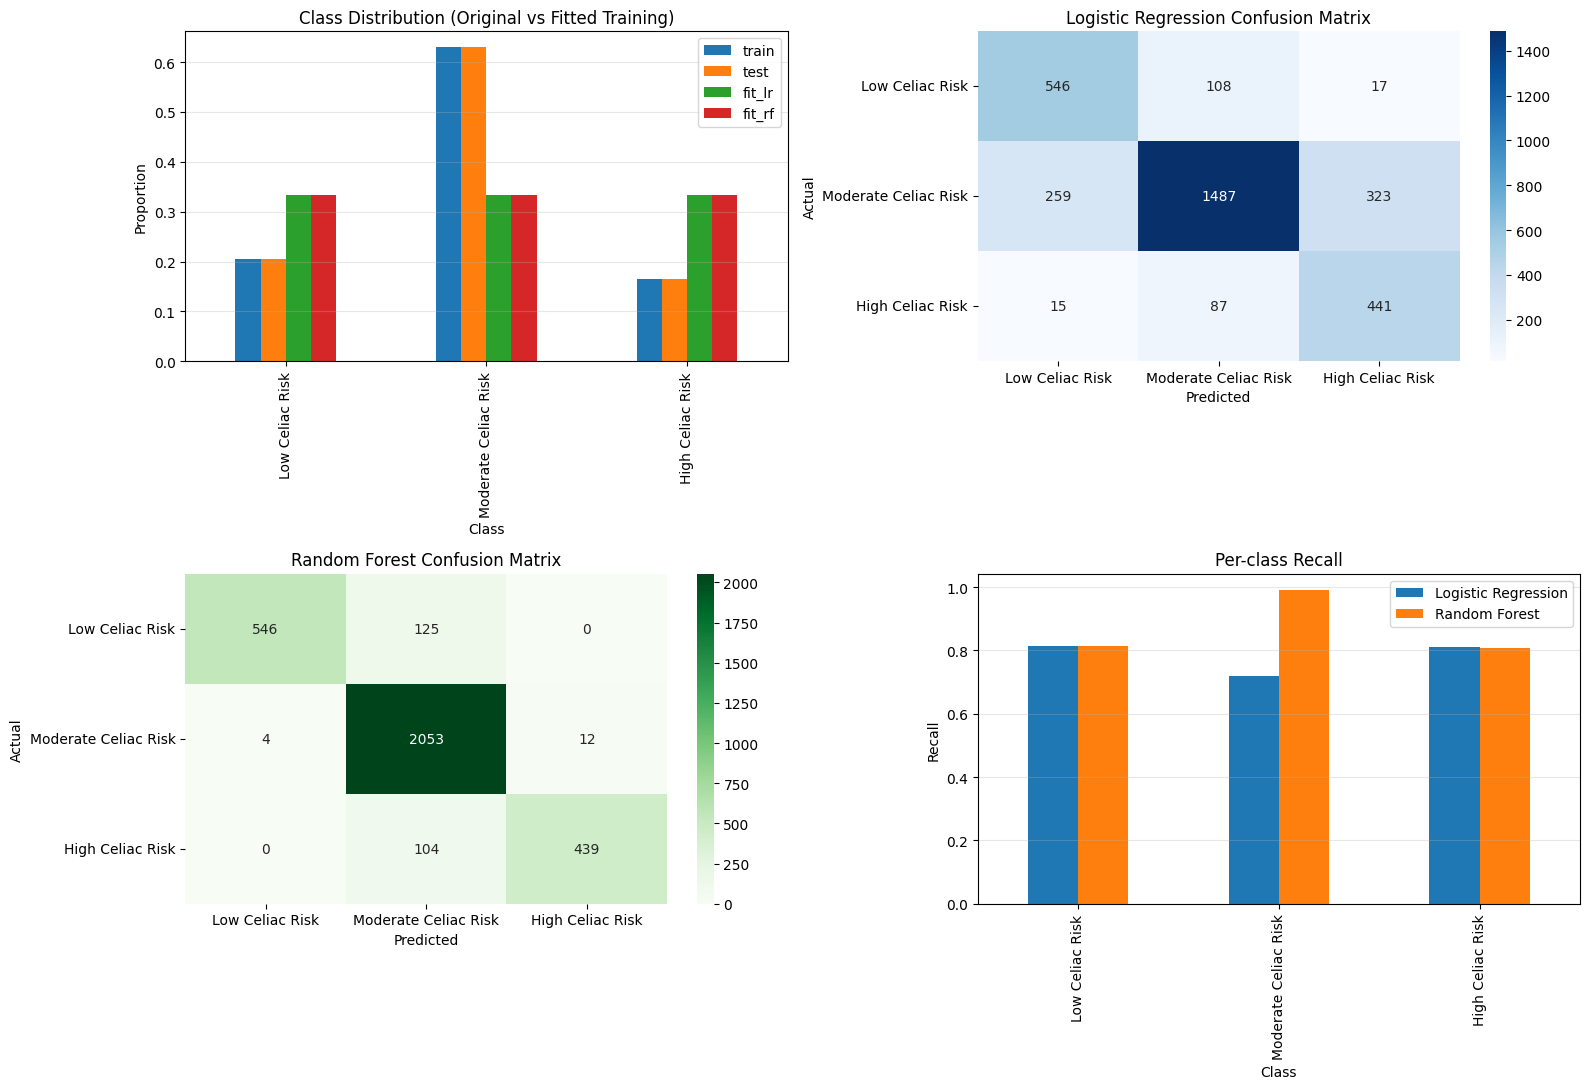

In [9]:
label_names = {0: "Low Celiac Risk", 1: "Moderate Celiac Risk", 2: "High Celiac Risk"}
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
fit_lr_dist = pd.Series(lr_metrics["fit_class_distribution"]).sort_index()
fit_rf_dist = pd.Series(rf_metrics["fit_class_distribution"]).sort_index()
dist_df = pd.DataFrame(
    {
        "train": train_dist,
        "test": test_dist,
        "fit_lr": fit_lr_dist,
        "fit_rf": fit_rf_dist,
    }
).fillna(0.0)
dist_df.index = [label_names.get(int(i), str(i)) for i in dist_df.index]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# Class distribution overview
ax = axes[0, 0]
dist_df.plot(kind="bar", ax=ax)
ax.set_title("Class Distribution (Original vs Fitted Training)")
ax.set_ylabel("Proportion")
ax.set_xlabel("Class")
ax.grid(axis="y", alpha=0.3)
# Confusion matrix: logistic regression
ax = axes[0, 1]
lr_labels = [label_names.get(int(i), str(i)) for i in lr_metrics["labels"]]
sns.heatmap(
    lr_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_labels,
    yticklabels=lr_labels,
    ax=ax,
)
ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
# Confusion matrix: random forest
ax = axes[1, 0]
rf_labels = [label_names.get(int(i), str(i)) for i in rf_metrics["labels"]]
sns.heatmap(
    rf_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_labels,
    yticklabels=rf_labels,
    ax=ax,
)
ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
# Per-class recall comparison
ax = axes[1, 1]
lr_recall = {}
for label in lr_metrics["labels"]:
    name = label_names.get(int(label), str(label))
    lr_recall[name] = lr_metrics["classification_report_dict"].get(name, {}).get("recall", 0.0)
rf_recall = {}
for label in rf_metrics["labels"]:
    name = label_names.get(int(label), str(label))
    rf_recall[name] = rf_metrics["classification_report_dict"].get(name, {}).get("recall", 0.0)
recall_df = pd.DataFrame({"Logistic Regression": pd.Series(lr_recall), "Random Forest": pd.Series(rf_recall)}).fillna(0.0)
recall_df.plot(kind="bar", ax=ax)
ax.set_title("Per-class Recall")
ax.set_ylabel("Recall")
ax.set_xlabel("Class")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Additional Report Charts
These charts are generated for report-friendly visuals and exported to `report_charts/`.


### Additional Report Charts (Inline View)

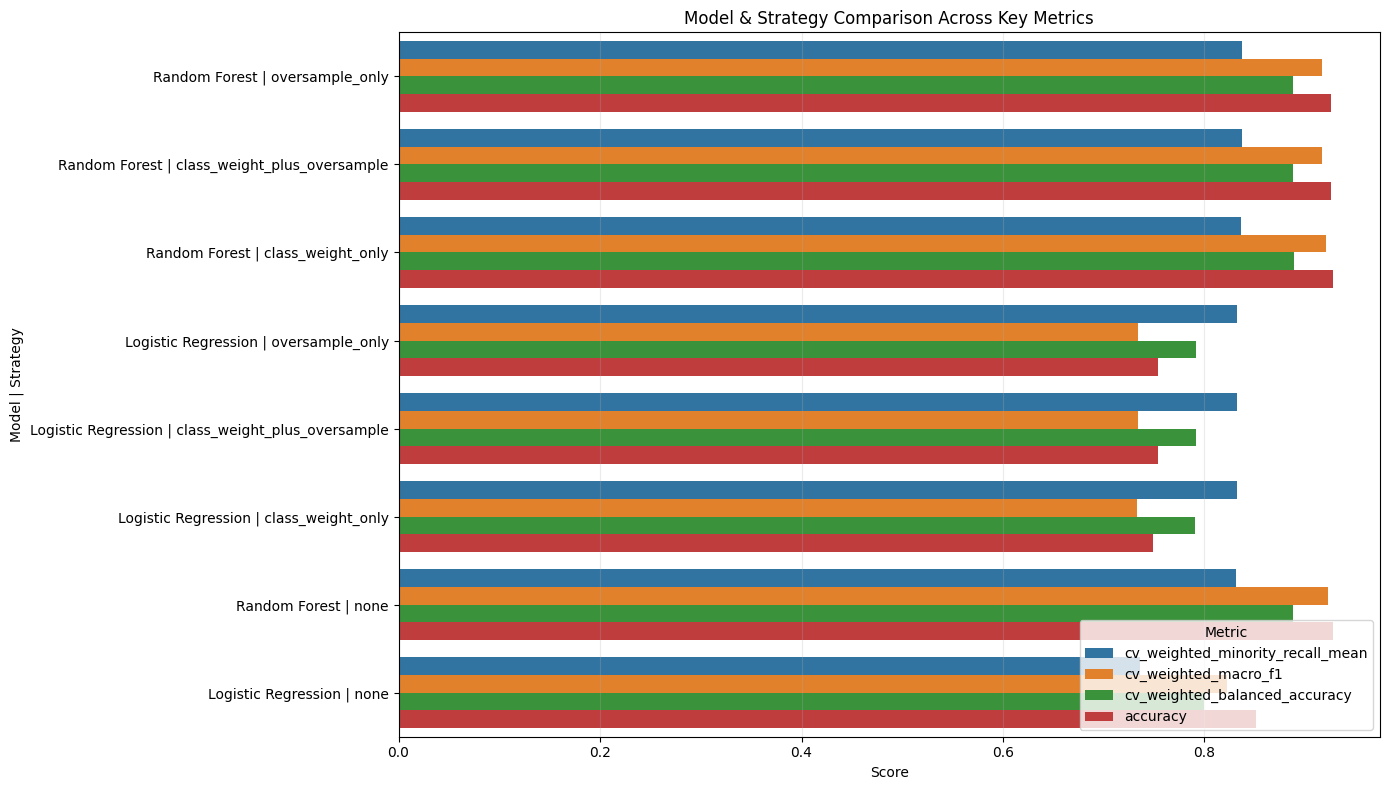

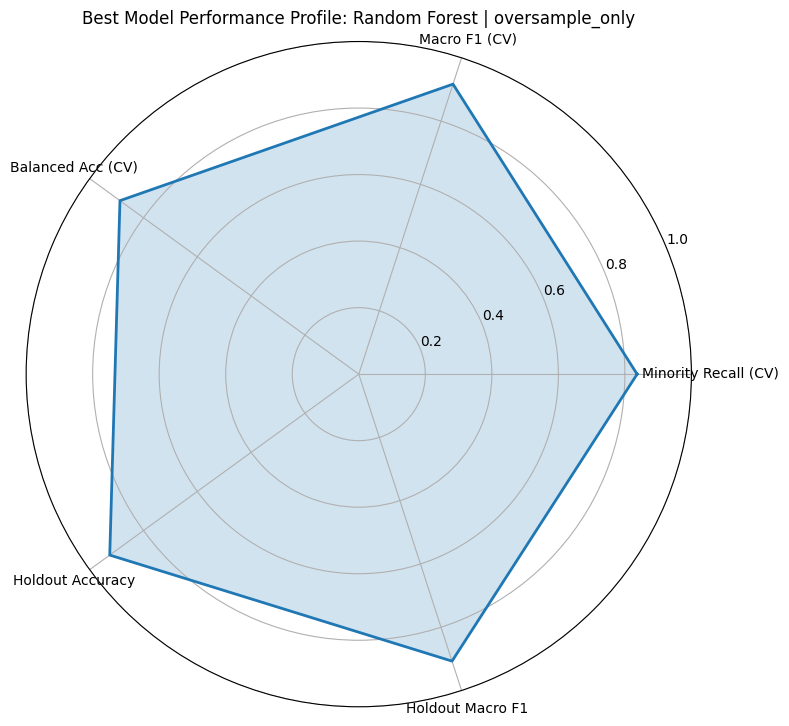

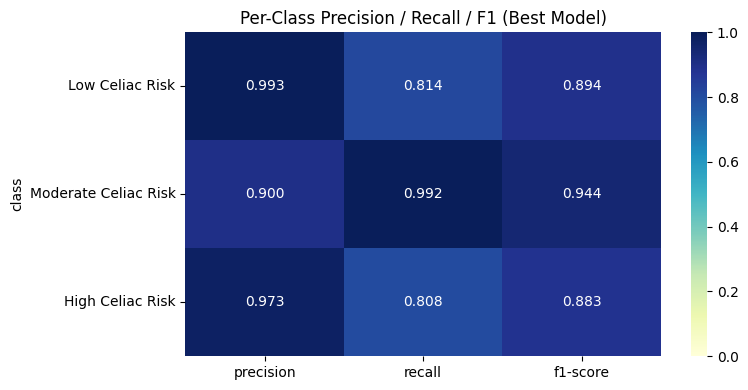

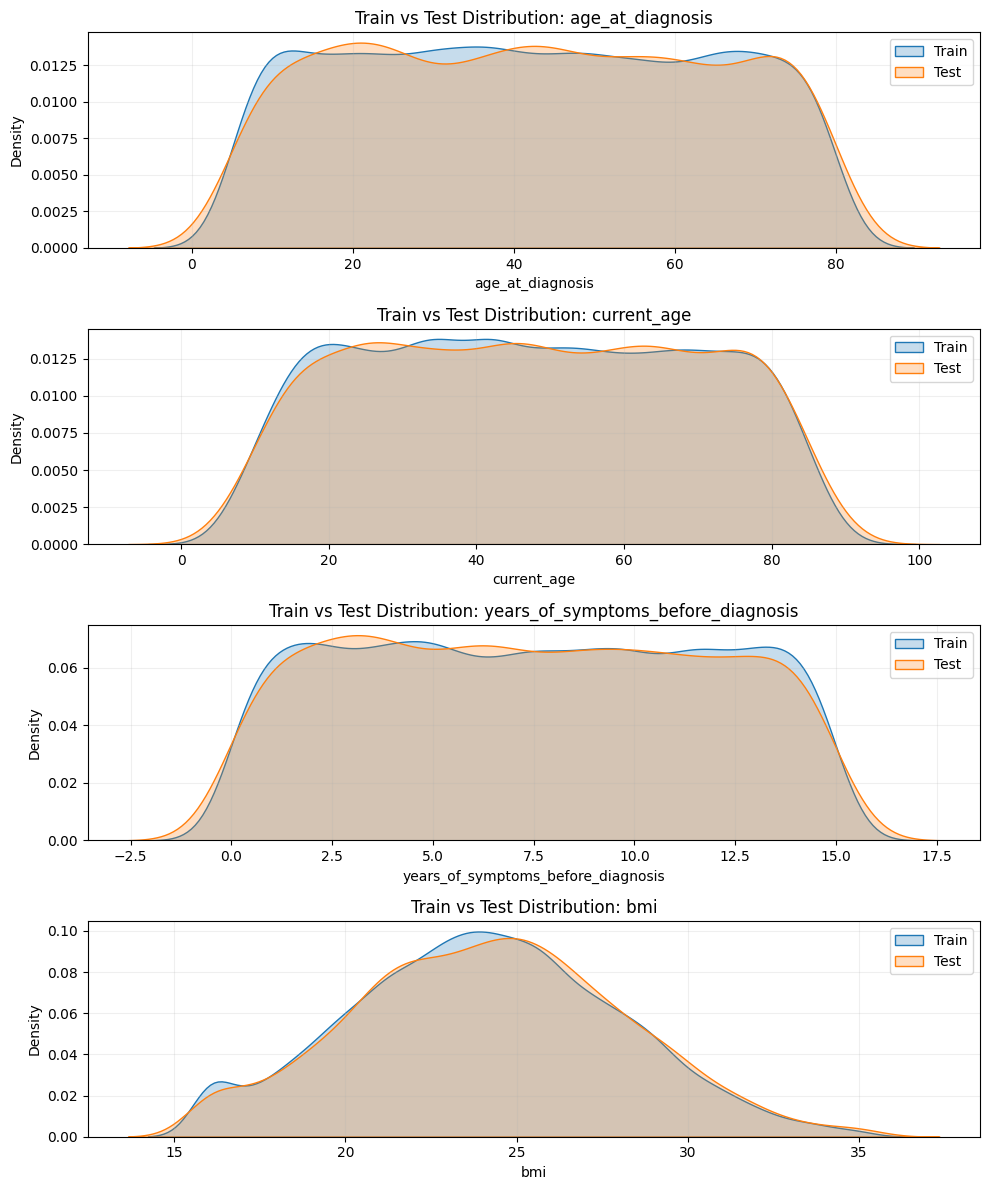

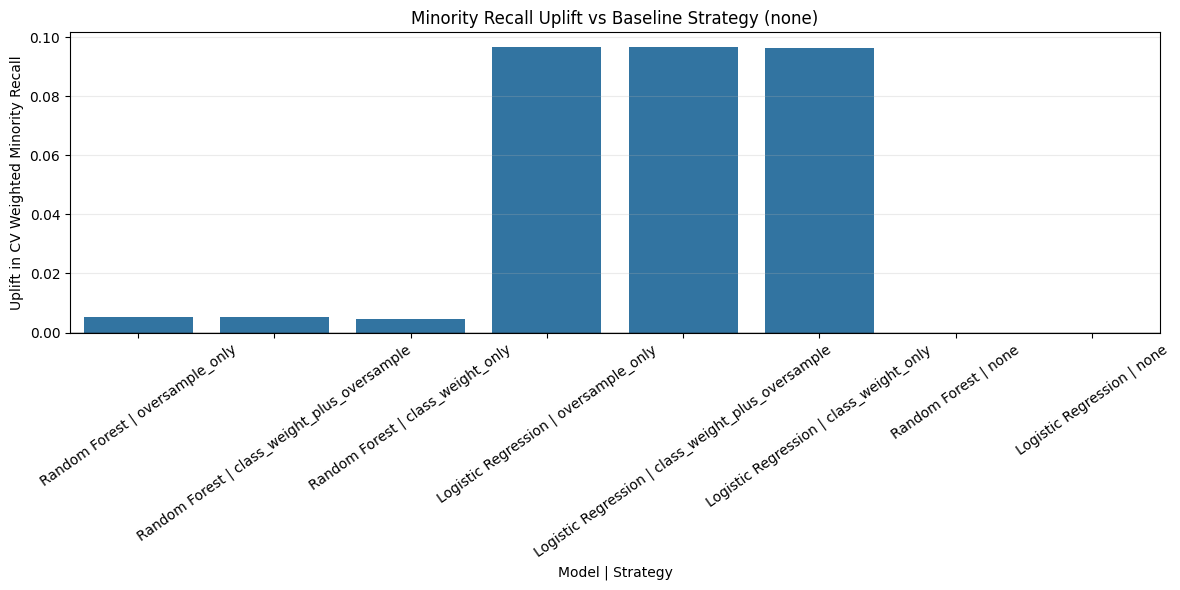

Additional charts exported to: D:\celiguard-ml\models\report_charts


In [10]:
from IPython.display import Markdown, display

# Additional report-ready charts
report_dir = OUTPUT_DIR / 'report_charts'
report_dir.mkdir(parents=True, exist_ok=True)

display(Markdown('### Additional Report Charts (Inline View)'))

summary_df = pd.DataFrame(all_metrics).sort_values([
    'cv_weighted_minority_recall_mean', 'cv_weighted_macro_f1', 'cv_weighted_balanced_accuracy'
], ascending=False).reset_index(drop=True)
summary_df['model_strategy'] = summary_df['name'] + ' | ' + summary_df['strategy']

# Local best selection for plotting (independent from later cells)
best_for_plots = max(
    all_metrics,
    key=lambda x: (x['cv_weighted_minority_recall_mean'], x['cv_weighted_macro_f1'], x['cv_weighted_balanced_accuracy'], x['accuracy'])
)

# 1) Ranked model-strategy performance across multiple metrics
plot_metrics = [
    'cv_weighted_minority_recall_mean',
    'cv_weighted_macro_f1',
    'cv_weighted_balanced_accuracy',
    'accuracy',
]
melted = summary_df[['model_strategy'] + plot_metrics].melt(
    id_vars='model_strategy', var_name='metric', value_name='score'
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=melted, x='score', y='model_strategy', hue='metric', ax=ax)
ax.set_title('Model & Strategy Comparison Across Key Metrics')
ax.set_xlabel('Score')
ax.set_ylabel('Model | Strategy')
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Metric', loc='lower right')
fig.tight_layout()
fig.savefig(report_dir / '01_model_strategy_metric_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# 2) Radar chart: best model profile
best_profile = {
    'Minority Recall (CV)': best_for_plots['cv_weighted_minority_recall_mean'],
    'Macro F1 (CV)': best_for_plots['cv_weighted_macro_f1'],
    'Balanced Acc (CV)': best_for_plots['cv_weighted_balanced_accuracy'],
    'Holdout Accuracy': best_for_plots['accuracy'],
    'Holdout Macro F1': best_for_plots['macro_f1'],
}
labels = list(best_profile.keys())
values = list(best_profile.values())
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Best Model Performance Profile: {best_for_plots['name']} | {best_for_plots['strategy']}")
fig.tight_layout()
fig.savefig(report_dir / '02_best_model_radar_profile.png', dpi=200, bbox_inches='tight')
plt.show()

# 3) Per-class precision/recall/F1 heatmap for best model
report_dict = best_for_plots.get('classification_report_dict', {})
class_rows = []
for cls_id, cls_name in label_names.items():
    if cls_name in report_dict:
        class_rows.append({
            'class': cls_name,
            'precision': report_dict[cls_name].get('precision', np.nan),
            'recall': report_dict[cls_name].get('recall', np.nan),
            'f1-score': report_dict[cls_name].get('f1-score', np.nan),
        })
class_metric_df = pd.DataFrame(class_rows).set_index('class')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(class_metric_df, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1, ax=ax)
ax.set_title('Per-Class Precision / Recall / F1 (Best Model)')
fig.tight_layout()
fig.savefig(report_dir / '03_per_class_metrics_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# 4) Feature distribution drift: train vs test (top numeric features)
num_cols = [c for c in ACTIVE_MODEL_NUMERIC_FEATURES if c in clean_train_df.columns and c in clean_test_df.columns]
top_num_cols = num_cols[:min(4, len(num_cols))]
if top_num_cols:
    fig, axes = plt.subplots(len(top_num_cols), 1, figsize=(10, 3 * len(top_num_cols)))
    if len(top_num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, top_num_cols):
        sns.kdeplot(clean_train_df[col], label='Train', ax=ax, fill=True, alpha=0.25)
        sns.kdeplot(clean_test_df[col], label='Test', ax=ax, fill=True, alpha=0.25)
        ax.set_title(f'Train vs Test Distribution: {col}')
        ax.grid(alpha=0.2)
        ax.legend()
    fig.tight_layout()
    fig.savefig(report_dir / '04_train_test_numeric_distribution_drift.png', dpi=200, bbox_inches='tight')
    plt.show()

# 5) Strategy uplift chart versus baseline (none)
baseline_rows = summary_df[summary_df['strategy'] == 'none'][['name', 'cv_weighted_minority_recall_mean']]
baseline_map = dict(zip(baseline_rows['name'], baseline_rows['cv_weighted_minority_recall_mean']))
uplift_df = summary_df.copy()
uplift_df['baseline_minority_recall'] = uplift_df['name'].map(baseline_map)
uplift_df['uplift_vs_none'] = uplift_df['cv_weighted_minority_recall_mean'] - uplift_df['baseline_minority_recall']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=uplift_df, x='model_strategy', y='uplift_vs_none', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Minority Recall Uplift vs Baseline Strategy (none)')
ax.set_xlabel('Model | Strategy')
ax.set_ylabel('Uplift in CV Weighted Minority Recall')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(report_dir / '05_strategy_uplift_vs_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Additional charts exported to: {report_dir.resolve()}')





In [11]:
# Primary objective: CV weighted minority recall.
# Tie-break with macro F1 / balanced accuracy, then prefer simpler strategy when within epsilon.
best = max(
    all_metrics,
    key=lambda x: (x['cv_weighted_minority_recall_mean'], x['cv_weighted_macro_f1'], x['cv_weighted_balanced_accuracy'], x['accuracy']),
)

EPSILON = 0.002
candidates = [
    m for m in all_metrics
    if (best['cv_weighted_minority_recall_mean'] - m['cv_weighted_minority_recall_mean']) <= EPSILON
]
if candidates:
    strategy_complexity = {
        'none': 0,
        'class_weight_only': 1,
        'oversample_only': 1,
        'class_weight_plus_oversample': 2,
    }
    best = max(
        candidates,
        key=lambda x: (
            x['cv_weighted_macro_f1'],
            x['cv_weighted_balanced_accuracy'],
            -strategy_complexity.get(x['strategy'], 99),
            x['accuracy'],
        ),
    )

best_model = best['pipeline']

print(f"Selected model: {best['name']} | strategy={best['strategy']}")
print(f"Selected decision weights: {best['decision_weights']}")
print(f"Selected CV weighted minority recall mean (Low/High): {best['cv_weighted_minority_recall_mean']:.4f}")
print(f"Selected CV weighted macro F1: {best['cv_weighted_macro_f1']:.4f}")
print(f"Selected CV weighted balanced accuracy: {best['cv_weighted_balanced_accuracy']:.4f}")
print(f"Selected holdout macro F1: {best['macro_f1']:.4f}")
print(f"Selected holdout balanced accuracy: {best['balanced_accuracy']:.4f}")
print(f"Selected holdout accuracy: {best['accuracy']:.4f}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

strategy_lookup = {s['name']: s for s in BALANCING_STRATEGIES}
selected_strategy = strategy_lookup[best['strategy']]

metadata = {
    "numeric_features": ACTIVE_MODEL_NUMERIC_FEATURES,
    "base_numeric_features": NUMERIC_FEATURES,
    "missing_indicator_features": MISSING_INDICATOR_FEATURES,
    "active_missing_indicators": ACTIVE_MISSING_INDICATORS,
    "categorical_features": CATEGORICAL_FEATURES,
    "model_type": best['name'],
    "selection_strategy": best['strategy'],
    "decision_weights": best['decision_weights'],
    "accuracy": best['accuracy'],
    "balanced_accuracy": best['balanced_accuracy'],
    "macro_f1": best['macro_f1'],
    "minority_recall_mean": best['minority_recall_mean'],
    "cv_accuracy": best['cv_accuracy'],
    "cv_balanced_accuracy": best['cv_balanced_accuracy'],
    "cv_macro_f1": best['cv_macro_f1'],
    "cv_minority_recall_mean": best['cv_minority_recall_mean'],
    "cv_weighted_macro_f1": best['cv_weighted_macro_f1'],
    "cv_weighted_balanced_accuracy": best['cv_weighted_balanced_accuracy'],
    "cv_weighted_minority_recall_mean": best['cv_weighted_minority_recall_mean'],
    "cv_folds": CV_FOLDS,
    "data_source": data_source,
    "target_mode": train_cleaning_report['target_mode'],
    "target_column": TARGET_COLUMN,
    "target_type": "celiac_serology_risk",
    "not_malignancy_model": True,
    "intended_use": "Research prototype for estimating celiac risk from the configured Hugging Face dataset.",
    "limitations": "Research prototype only; not for clinical diagnosis or treatment decisions.",
    "effective_feature_note": "Feature coverage and quality depend on the configured Hugging Face dataset schema.",
    "class_weight_balancing": selected_strategy['class_weight'],
    "random_oversampling": selected_strategy['oversample'],
}

joblib.dump(best_model, OUTPUT_MODEL_PATH)
joblib.dump(metadata, OUTPUT_METADATA_PATH)

print(f"Saved model: {OUTPUT_MODEL_PATH.resolve()}")
print(f"Saved metadata: {OUTPUT_METADATA_PATH.resolve()}")



Selected model: Random Forest | strategy=class_weight_only
Selected decision weights: {0: 1.3, 1: 1.0, 2: 1.2}
Selected CV weighted minority recall mean (Low/High): 0.8360
Selected CV weighted macro F1: 0.9211
Selected CV weighted balanced accuracy: 0.8889
Selected holdout macro F1: 0.9093
Selected holdout balanced accuracy: 0.8720
Selected holdout accuracy: 0.9272
Saved model: D:\celiguard-ml\models\celiac_risk_model.pkl
Saved metadata: D:\celiguard-ml\models\model_metadata.pkl


In [12]:
sample = X_test.iloc[[0]].copy()
sample_truth = int(y_test.iloc[0])
sample_pred = int(best_model.predict(sample)[0])
sample_proba = best_model.predict_proba(sample)[0]
risk_labels = {0: "Low Celiac Risk", 1: "Moderate Celiac Risk", 2: "High Celiac Risk"}
print("Smoke test prediction:")
print(f"Ground truth: {sample_truth} ({risk_labels[sample_truth]})")
print(f"Predicted: {sample_pred} ({risk_labels[sample_pred]})")
print(f"Probabilities [Low, Moderate, High]: {sample_proba}")


Smoke test prediction:
Ground truth: 1 (Moderate Celiac Risk)
Predicted: 1 (Moderate Celiac Risk)
Probabilities [Low, Moderate, High]: [0.18214621 0.67221034 0.14564345]


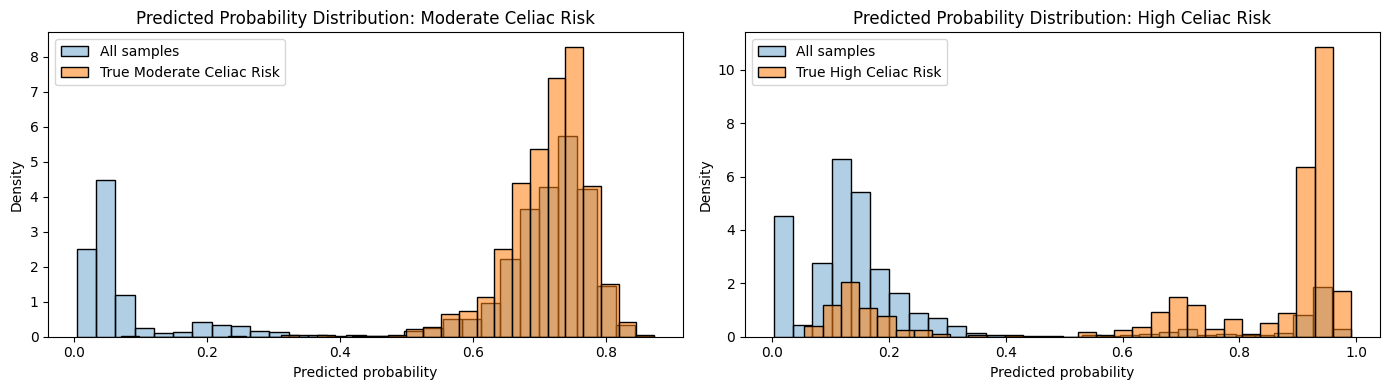

In [13]:
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_test)
    class_to_idx = {int(c): idx for idx, c in enumerate(best_model.classes_)}
    classes_to_plot = [cls for cls in [1, 2] if cls in class_to_idx]
    if not classes_to_plot:
        classes_to_plot = [int(best_model.classes_[0])]
    fig, axes = plt.subplots(1, len(classes_to_plot), figsize=(7 * len(classes_to_plot), 4))
    if len(classes_to_plot) == 1:
        axes = [axes]
    for ax, cls in zip(axes, classes_to_plot):
        idx = class_to_idx[cls]
        cls_name = label_names.get(int(cls), f"Class {cls}")
        all_scores = proba[:, idx]
        positive_scores = all_scores[y_test.values == cls]
        sns.histplot(all_scores, bins=30, stat="density", alpha=0.35, label="All samples", ax=ax)
        if len(positive_scores) > 0:
            sns.histplot(positive_scores, bins=30, stat="density", alpha=0.55, label=f"True {cls_name}", ax=ax)
        ax.set_title(f"Predicted Probability Distribution: {cls_name}")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Density")
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Best model has no predict_proba; skipping probability plots")
